In [78]:
import pandas as pd   # Untuk membuat dan mengolah DataFrame
import numpy as np    # Untuk operasi matematika (sqrt, array, dll)
import matplotlib.pyplot as plt   # Untuk membuat grafik/visualisasi
from sklearn.model_selection import train_test_split  # Membagi data train & test
from sklearn.linear_model import LinearRegression     # Model regresi linear
from sklearn import metrics   # Untuk evaluasi model (MAE, MSE, RMSE)

In [80]:
# Dataset
data = {
    'biaya_iklan': [1,2,3,4,5,6,7,8,9,10,11,12,13,14],           # Juta rupiah
    'jangkauan':   [30,44,53,57,65,68,74,79,83,87,90,93,95,99],  # % audiens
    'kreativitas': [5,5,6,6,7,7,7,8,8,8,9,9,9,9],                # Skor 1-10
    'durasi_iklan':[6,6,7,7,7,8,8,8,7,7,7,7,8,8],                # Jam tayang/hari
    'diskon':      [10,17,20,28,30,36,25,31,10,30,40,20,15,40],  # % diskon
    'penjualan':   [50,54,58,62,66,70,74,78,82,86,90,95,100,100] # Unit terjual (ratusan)
}

# Mengubah dictionary menjadi DataFrame agar mudah diolah
df = pd.DataFrame(data)
print(df)   # Menampilkan seluruh data dalam bentuk tabel

    biaya_iklan  jangkauan  kreativitas  durasi_iklan  diskon  penjualan
0             1         30            5             6      10         50
1             2         44            5             6      17         54
2             3         53            6             7      20         58
3             4         57            6             7      28         62
4             5         65            7             7      30         66
5             6         68            7             8      36         70
6             7         74            7             8      25         74
7             8         79            8             8      31         78
8             9         83            8             7      10         82
9            10         87            8             7      30         86
10           11         90            9             7      40         90
11           12         93            9             7      20         95
12           13         95            9            

In [81]:
# Menentukan variabel dengan 5 fitur
X = df[['biaya_iklan', 'jangkauan', 'kreativitas', 'durasi_iklan', 'diskon']]
y = df['penjualan']

In [82]:
# Split data train dan test
# Test_size=0.2  → 20% data untuk testing, 80% untuk training
# Random_state=42 → agar hasil pembagian selalu sama setiap dijalankan
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [83]:
# Membuat model regresi
model = LinearRegression()
model.fit(x_train, y_train)  # Model menggunakan data training

LinearRegression()

In [84]:
# Melihat atau menghitung koefisien
# Rumus regresi linear berganda:
# y = a + b1*biaya_iklan + b2*jangkauan + b3*kreativitas + b4*durasi_iklan + b5*diskon
print("Intercept (a) :", model.intercept_)
print("Koefisien (b) :", model.coef_)

Intercept (a) : 41.42722735624583
Koefisien (b) : [ 4.29316913 -0.24735089  2.29959006  0.74987307 -0.07237573]


In [85]:
# Prediksi data testing
y_pred = model.predict(x_test)

print("Penjualan Asli:", y_pred)
print("Penjualan Prediksi:", y_test.values)

Penjualan Asli: [84.31395111 94.43953136 53.57330114]
Penjualan Prediksi: [86 95 50]


In [86]:
# Evaluasi
print("MAE :", metrics.mean_absolute_error(y_test, y_pred))   # MAE: rata-rata selisih absolut prediksi vs asli (semakin kecil semakin baik)
print("MSE :", metrics.mean_squared_error(y_test, y_pred))    # MSE: rata-rata kuadrat selisih (lebih sensitif terhadap error besar)
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred))) # RMSE:akar MSE, satuannya sama dengan data asli (ratusan unit)

MAE : 1.9399395564215471
MSE : 5.308455671371601
RMSE: 2.304008609222544


In [87]:
# Prediksi data baru
data_baru = np.array([[14, 90, 8, 7, 25]])

prediksi = model.predict(data_baru)

print("Prediksi penjualan:", prediksi[0])

Prediksi penjualan: 101.10645359662787


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


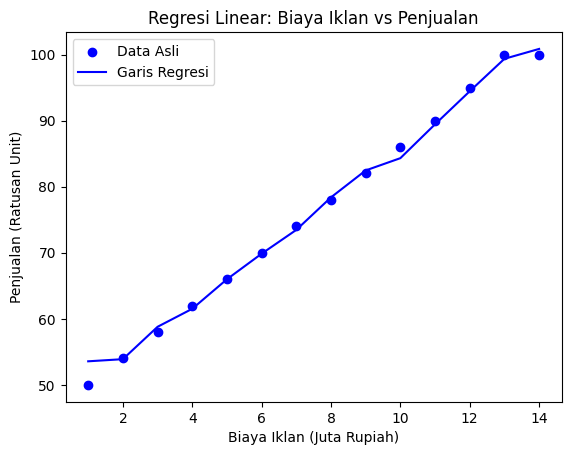

In [88]:
plt.scatter(df['biaya_iklan'], y, label="Data Asli", color='blue')
plt.plot(df['biaya_iklan'], model.predict(X), label="Garis Regresi", color='blue')
plt.xlabel("Biaya Iklan (Juta Rupiah)")
plt.ylabel("Penjualan (Ratusan Unit)")
plt.title("Regresi Linear: Biaya Iklan vs Penjualan")
plt.legend()  # menampilkan keterangan warna titik/garis
plt.show()    # menampilkan grafik